<a href="https://colab.research.google.com/github/aakankshalahane/SQL-Projects-/blob/main/Banking_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,transaction_id,customer_id,transaction_type,amount,transaction_date,location,status
0,101,1,Purchase,2500,2026-01-05,Mumbai,Success
1,102,1,Withdrawal,15000,2026-01-06,Mumbai,Success
2,103,2,Transfer,75000,2026-01-07,Pune,Success
3,104,3,Purchase,1800,2026-01-08,Delhi,Success
4,105,4,Withdrawal,50000,2026-01-09,Mumbai,Success
5,106,5,Transfer,120000,2026-01-10,Bangalore,Success
6,107,6,Purchase,3200,2026-01-11,Pune,Success
7,108,7,Transfer,150000,2026-01-12,Delhi,Failed
8,109,8,Withdrawal,42000,2026-01-13,Mumbai,Success
9,110,9,Purchase,2200,2026-01-14,Hyderabad,Success


Customer Transaction Summary


,customer_name,city,account_type,transaction_count,total_transaction_amount
0,Amit,Bangalore,Current,2,210000
1,Rohan,Delhi,Current,2,156500
2,Sneha,Mumbai,Savings,2,135000
3,Isha,Mumbai,Savings,2,112000
4,Meera,Bangalore,Current,1,90000
5,Aarav,Mumbai,Savings,3,87500
6,Priya,Pune,Current,2,79500
7,Neha,Pune,Savings,2,63200
8,Karan,Hyderabad,Savings,2,42200
9,Rahul,Delhi,Savings,2,31800


High Value Transactions


,customer_name,transaction_type,amount,transaction_date,location
0,Rohan,Transfer,150000,2026-01-12,Delhi
1,Amit,Transfer,120000,2026-01-10,Bangalore
2,Meera,Transfer,90000,2026-01-15,Bangalore
3,Amit,Withdrawal,90000,2026-01-20,Bangalore
4,Sneha,Transfer,85000,2026-01-19,Delhi
5,Priya,Transfer,75000,2026-01-07,Pune
6,Aarav,Transfer,70000,2026-01-16,Delhi
7,Isha,Transfer,70000,2026-01-23,Delhi
8,Neha,Transfer,60000,2026-01-21,Delhi


...

,customer_name,total_transactions,failed_transactions,risk_level
0,Karan,2,1,Medium Risk
1,Rohan,2,1,Medium Risk
2,Neha,2,1,Medium Risk
3,Rahul,2,1,Medium Risk
4,Aarav,3,1,Medium Risk
5,Meera,1,0,Low Risk
6,Isha,2,0,Low Risk
7,Amit,2,0,Low Risk
8,Sneha,2,0,Low Risk
9,Priya,2,0,Low Risk


CTE High Risk Analysis


,customer_name,transaction_type,amount,status,location
0,Rohan,Transfer,150000,Failed,Delhi
1,Amit,Transfer,120000,Success,Bangalore
2,Meera,Transfer,90000,Success,Bangalore
3,Amit,Withdrawal,90000,Success,Bangalore
4,Sneha,Transfer,85000,Success,Delhi
5,Priya,Transfer,75000,Success,Pune
6,Aarav,Transfer,70000,Failed,Delhi
7,Isha,Transfer,70000,Success,Delhi
8,Neha,Transfer,60000,Failed,Delhi
9,Karan,Withdrawal,40000,Failed,Mumbai


Customer Transaction Ranking


,customer_name,total_amount,transaction_rank
0,Amit,210000,1
1,Rohan,156500,2
2,Sneha,135000,3
3,Isha,112000,4
4,Meera,90000,5
5,Aarav,87500,6
6,Priya,79500,7
7,Neha,63200,8
8,Karan,42200,9
9,Rahul,31800,10


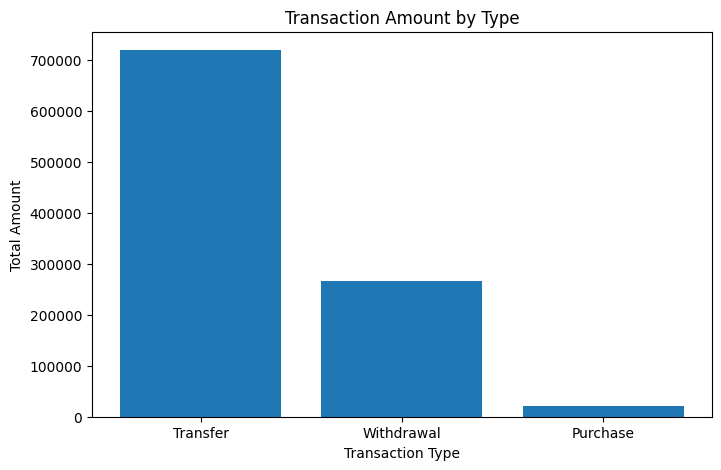

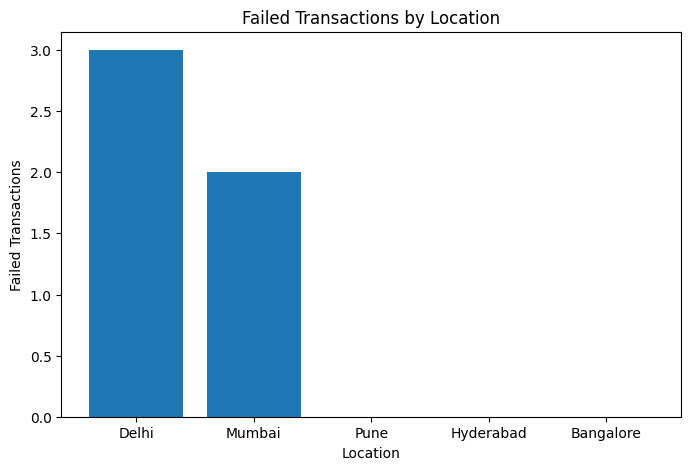

Database connection closed successfully


In [ ]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Create database
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Create customers table
cursor.execute("""
CREATE TABLE customers (
    customer_id INT,
    customer_name VARCHAR(50),
    city VARCHAR(50),
    account_type VARCHAR(30),
    account_balance DECIMAL(12,2)
)
""")

# Create transactions table
cursor.execute("""
CREATE TABLE transactions (
    transaction_id INT,
    customer_id INT,
    transaction_type VARCHAR(30),
    amount DECIMAL(12,2),
    transaction_date DATE,
    location VARCHAR(50),
    status VARCHAR(20)
)
""")

# Insert customer dataset
cursor.executemany("""
INSERT INTO customers VALUES (?, ?, ?, ?, ?)
""", [
    (1,'Aarav','Mumbai','Savings',85000),
    (2,'Priya','Pune','Current',125000),
    (3,'Rahul','Delhi','Savings',65000),
    (4,'Sneha','Mumbai','Savings',95000),
    (5,'Amit','Bangalore','Current',180000),
    (6,'Neha','Pune','Savings',72000),
    (7,'Rohan','Delhi','Current',210000),
    (8,'Isha','Mumbai','Savings',56000),
    (9,'Karan','Hyderabad','Savings',90000),
    (10,'Meera','Bangalore','Current',150000)
])

# Insert transaction dataset
cursor.executemany("""
INSERT INTO transactions VALUES (?, ?, ?, ?, ?, ?, ?)
""", [
    (101,1,'Purchase',2500,'2026-01-05','Mumbai','Success'),
    (102,1,'Withdrawal',15000,'2026-01-06','Mumbai','Success'),
    (103,2,'Transfer',75000,'2026-01-07','Pune','Success'),
    (104,3,'Purchase',1800,'2026-01-08','Delhi','Success'),
    (105,4,'Withdrawal',50000,'2026-01-09','Mumbai','Success'),
    (106,5,'Transfer',120000,'2026-01-10','Bangalore','Success'),
    (107,6,'Purchase',3200,'2026-01-11','Pune','Success'),
    (108,7,'Transfer',150000,'2026-01-12','Delhi','Failed'),
    (109,8,'Withdrawal',42000,'2026-01-13','Mumbai','Success'),
    (110,9,'Purchase',2200,'2026-01-14','Hyderabad','Success'),
    (111,10,'Transfer',90000,'2026-01-15','Bangalore','Success'),
    (112,1,'Transfer',70000,'2026-01-16','Delhi','Failed'),
    (113,2,'Purchase',4500,'2026-01-17','Pune','Success'),
    (114,3,'Withdrawal',30000,'2026-01-18','Mumbai','Failed'),
    (115,4,'Transfer',85000,'2026-01-19','Delhi','Success'),
    (116,5,'Withdrawal',90000,'2026-01-20','Bangalore','Success'),
    (117,6,'Transfer',60000,'2026-01-21','Delhi','Failed'),
    (118,7,'Purchase',6500,'2026-01-22','Delhi','Success'),
    (119,8,'Transfer',70000,'2026-01-23','Delhi','Success'),
    (120,9,'Withdrawal',40000,'2026-01-24','Mumbai','Failed')
])

conn.commit()

# View transaction data
transactions = pd.read_sql_query("""
SELECT *
FROM transactions
""", conn)

display(transactions)

# Customer transaction summary
customer_summary = pd.read_sql_query("""
SELECT
    c.customer_name,
    c.city,
    c.account_type,
    COUNT(t.transaction_id) AS transaction_count,
    SUM(t.amount) AS total_transaction_amount
FROM customers c
JOIN transactions t
ON c.customer_id = t.customer_id
GROUP BY c.customer_id
ORDER BY total_transaction_amount DESC
""", conn)

print("Customer Transaction Summary")
display(customer_summary)

# High value transactions
high_value = pd.read_sql_query("""
SELECT
    c.customer_name,
    t.transaction_type,
    t.amount,
    t.transaction_date,
    t.location
FROM customers c
JOIN transactions t
ON c.customer_id = t.customer_id
WHERE t.amount > 50000
ORDER BY t.amount DESC
""", conn)

print("High Value Transactions")
display(high_value)

# Failed transactions
failed_transactions = pd.read_sql_query("""
SELECT
    c.customer_name,
    t.transaction_type,
    t.amount,
    t.transaction_date,
    t.location
FROM customers c
JOIN transactions t
ON c.customer_id = t.customer_id
WHERE t.status = 'Failed'
ORDER BY t.amount DESC
""", conn)

print("Failed Transactions")
display(failed_transactions)

# Fraud risk customers
fraud_risk = pd.read_sql_query("""
SELECT
    c.customer_name,
    COUNT(t.transaction_id) AS failed_transactions,
    SUM(t.amount) AS failed_amount
FROM customers c
JOIN transactions t
ON c.customer_id = t.customer_id
WHERE t.status = 'Failed'
GROUP BY c.customer_id
HAVING COUNT(t.transaction_id) >= 1
ORDER BY failed_amount DESC
""", conn)

print("Potential Fraud Risk Customers")
display(fraud_risk)

# Transaction type analysis
transaction_analysis = pd.read_sql_query("""
SELECT
    transaction_type,
    COUNT(*) AS transaction_count,
    SUM(amount) AS total_amount,
    ROUND(AVG(amount), 2) AS average_amount
FROM transactions
GROUP BY transaction_type
ORDER BY total_amount DESC
""", conn)

print("Transaction Type Analysis")
display(transaction_analysis)

# Location analysis
location_analysis = pd.read_sql_query("""
SELECT
    location,
    COUNT(*) AS transaction_count,
    SUM(amount) AS total_amount,
    SUM(CASE WHEN status = 'Failed' THEN 1 ELSE 0 END) AS failed_transactions
FROM transactions
GROUP BY location
ORDER BY failed_transactions DESC
""", conn)

print("Location Risk Analysis")
display(location_analysis)

# Fraud risk scoring
risk_scores = pd.read_sql_query("""
SELECT
    c.customer_name,
    COUNT(t.transaction_id) AS total_transactions,
    SUM(CASE WHEN t.status = 'Failed' THEN 1 ELSE 0 END) AS failed_transactions,
    CASE
        WHEN SUM(CASE WHEN t.status = 'Failed' THEN 1 ELSE 0 END) >= 2 THEN 'High Risk'
        WHEN SUM(CASE WHEN t.status = 'Failed' THEN 1 ELSE 0 END) = 1 THEN 'Medium Risk'
        ELSE 'Low Risk'
    END AS risk_level
FROM customers c
JOIN transactions t
ON c.customer_id = t.customer_id
GROUP BY c.customer_id
ORDER BY failed_transactions DESC
""", conn)

print("Fraud Risk Score")
display(risk_scores)

# CTE for high risk transactions
cte_analysis = pd.read_sql_query("""
WITH high_risk AS (
    SELECT *
    FROM transactions
    WHERE amount > 50000
       OR status = 'Failed'
)
SELECT
    c.customer_name,
    h.transaction_type,
    h.amount,
    h.status,
    h.location
FROM high_risk h
JOIN customers c
ON h.customer_id = c.customer_id
ORDER BY h.amount DESC
""", conn)

print("CTE High Risk Analysis")
display(cte_analysis)

# Rank customers by transaction amount
ranked_customers = pd.read_sql_query("""
SELECT
    c.customer_name,
    SUM(t.amount) AS total_amount,
    RANK() OVER (
        ORDER BY SUM(t.amount) DESC
    ) AS transaction_rank
FROM customers c
JOIN transactions t
ON c.customer_id = t.customer_id
GROUP BY c.customer_id
""", conn)

print("Customer Transaction Ranking")
display(ranked_customers)

# Visualize transaction type
plt.figure(figsize=(8,5))
plt.bar(
    transaction_analysis["transaction_type"],
    transaction_analysis["total_amount"]
)
plt.title("Transaction Amount by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount")
plt.show()

# Visualize failed transactions
plt.figure(figsize=(8,5))
plt.bar(
    location_analysis["location"],
    location_analysis["failed_transactions"]
)
plt.title("Failed Transactions by Location")
plt.xlabel("Location")
plt.ylabel("Failed Transactions")
plt.show()

# Close database
conn.close()

print("Database connection closed successfully")